# Setup & Installation

This notebook requires **three separate packages** installed in the same Python environment.
All three use JAX and must share compatible `jax`/`jaxlib` versions.

### 1 · CTDS-JAX (Kash's JAX implementation)

```bash
git clone https://github.com/kasherri/ctds.git
cd ctds
pip install -e .
```

Core dependencies installed automatically:
`jax>=0.4.20`, `jaxlib>=0.4.20`, `dynamax>=0.1.4`, `scipy`, `numpy`, `matplotlib`, `seaborn`, `optax`, `chex`, `jaxtyping`, `tensorflow-probability`

---
### 2 · Jeremy's implementation (`pillow_lab_rotation`)

For my fork of Jeremy's implemention repo that already has this notebook:
```bash
git clone https://github.com/kasherri/ctds_jeremy_implemention.git
cd ctds_jeremy_implemention
pip install -e .
```

Requires **MOSEK** for the constrained QP M-step (via `cvxpy`):

```bash
pip install cvxpy mosek
```

> **MOSEK licence:** academic licences are free at https://www.mosek.com/products/academic-licenses/.  
> Place the licence file at `~/mosek/mosek.lic` before running.

---
### 3 · SSM (Aditi's SSM fork with `gaussian_ctds` dynamics)

SSM is not on PyPI so install the custom fork directly from your local clone of `ctds_jeremy_implemention` (it ships the vendored SSM):

```bash
cd ctds_jeremy_implemention/vendor/Cell_type_dynamical_system/ssm
pip install -e .
```

Or if you have a standalone copy of the SSM repo:
```bash
git clone <your-ssm-fork-url>
cd ssm
pip install -e .
```

---

### 4 · Notebook extras

```bash
pip install jupyter ipykernel seaborn scipy-hungarian
```

---

### 5 · JAX GPU/CPU backend (optional)

CPU (default, works everywhere):
```bash
pip install --upgrade "jax[cpu]"
```

GPU (CUDA 12):
```bash
pip install --upgrade "jax[cuda12]"
```

---
### quick sanity check

Run this cell after installation to confirm all three packages import properly:

```python
import jax; jax.config.update("jax_enable_x64", True)
from ctds.models import CTDS
from pillow_lab_rotation.jax_ctds import CTDSJax
import ssm; from ssm import LDS
print("All imports OK ✓")
print(f"JAX version: {jax.__version__}")
```

In [1]:
import jax
jax.config.update("jax_enable_x64", True)

In [2]:
import warnings
warnings.filterwarnings("ignore")

import os
import time
import pickle
print(os.environ)
import numpy as np
import jax.numpy as jnp
import jax.random as jr
import scipy

import matplotlib
import matplotlib.pyplot as plt
plt.style.use('default')
import sys
sys.path.insert(0, "/Users/kash/Documents/PNI/ctds_jeremy_implemention/src")
# CTDS-JAX
from ctds.models import CTDS
from ctds.params import (
    ParamsCTDS,
    ParamsCTDSInitial,
    ParamsCTDSDynamics,
    ParamsCTDSEmissions,
)
from ctds.simulation_utils import (
    generate_CTDS_Params,
    generate_random_CTDS_params,
    transform_true_rec_hungarian,
)

# Jeremy's CTDSJax
from pillow_lab_rotation import jax_ctds
CTDSJax=jax_ctds.CTDSJax

# SSM
import ssm
from ssm import LDS


print("All imports successful.")

environ({'COMMAND_MODE': 'unix2003', 'CONDA_DEFAULT_ENV': 'base', 'CONDA_EXE': '/Users/kash/documents/music/enter/bin/conda', 'CONDA_PREFIX': '/Users/kash/documents/music/enter', 'CONDA_PROMPT_MODIFIER': '(base) ', 'CONDA_PYTHON_EXE': '/Users/kash/documents/music/enter/bin/python', 'CONDA_SHLVL': '1', 'HOME': '/Users/kash', 'LOGNAME': 'kash', 'LaunchInstanceID': 'DB9DC699-C605-4C03-8622-3DBD28593EF1', 'MACH_PORT_RENDEZVOUS_PEER_VALDATION': '0', 'MallocNanoZone': '0', 'OLDPWD': '/', 'PATH': '/Users/kash/Documents/Music/enter/bin:/Users/kash/documents/music/enter/bin:/Users/kash/documents/music/enter/condabin:/Library/Frameworks/Python.framework/Versions/3.11/bin:/usr/local/bin:/System/Cryptexes/App/usr/bin:/usr/bin:/bin:/usr/sbin:/sbin:/var/run/com.apple.security.cryptexd/codex.system/bootstrap/usr/local/bin:/var/run/com.apple.security.cryptexd/codex.system/bootstrap/usr/bin:/var/run/com.apple.security.cryptexd/codex.system/bootstrap/usr/appleinternal/bin:/usr/local/share/dotnet:~/.dotn

In [3]:
# ── Dimensions ──────────────────────────────────────────────────────────────
D = 4; N = 20; T = 100
De = 2; Di = 2; Ne = 10; Ni = 10
N_TRIALS = 50; TRAIN_FRAC = 0.8; N_EM_ITERS = 200
n_train = 40; n_test = 10

# ── Cell-type arrays ────────────────────────────────────────────────────────
cell_types            = jnp.array([0, 1])
cell_sign             = jnp.array([1, -1])
cell_type_dimensions  = jnp.array([2, 2])
cell_type_mask        = jnp.concatenate(
    [jnp.zeros(10, dtype=jnp.int32), jnp.ones(10, dtype=jnp.int32)]
)
cell_type_neuron_count = jnp.array([10, 10])

default_config = {
    'cell_type_dimensions':   cell_type_dimensions,
    'cell_sign':              cell_sign,
    'cell_type_mask':         cell_type_mask,
    'cell_type_neuron_count': cell_type_neuron_count,
}

# ── SSM identity arrays ──────────────────────────────────────────────────────
region_identity    = np.zeros(N, dtype=int)
cell_type_identity = np.concatenate(
    [np.ones(Ne, dtype=int), 2 * np.ones(Ni, dtype=int)]
)
list_of_dims_2d = np.array([[De, Di]])   # shape (1,2) for SSM and transform_true_rec_hungarian

# ── Plotting palette ─────────────────────────────────────────────────────────
IMPL_LABELS  = ["CTDS-JAX", "Jeremy", "SSM"]
IMPL_COLORS  = ["#1f77b4", "#ff7f0e", "#2ca02c"]
INIT_LABELS  = ["Shared Init", "Native Init", "Random Init"]
INIT_COLORS  = ["#9467bd", "#8c564b", "#e377c2"]

FIG_DIR = "figures/benchmark"
os.makedirs(FIG_DIR, exist_ok=True)

key = jr.PRNGKey(42)
np.random.seed(42)

print("Constants and configuration set.")

Constants and configuration set.


In [4]:
# ── Shared helper functions ───────────────────────────────────────────────────

def make_ssm_ctds():
    """Create a fresh SSM CTDS model."""
    return LDS(
        N=N, D=D, M=0,
        dynamics="gaussian_ctds",
        emissions="gaussian_ctds",
        emission_kwargs=dict(
            cell_identity=cell_type_identity,
            region_identity=region_identity,
            list_of_dimensions=list_of_dims_2d,
        ),
        dynamics_kwargs=dict(list_of_dimensions=list_of_dims_2d),
    )


def load_params_into_jeremy(model, A, C, Q, R, mu0, Q0):
    """Set Jeremy model attributes from numpy/JAX arrays."""
    model.A   = jnp.array(A)
    model.C   = jnp.array(C)
    model.Q   = jnp.array(Q)
    model.R   = jnp.array(R)
    model.mu0 = jnp.array(mu0).reshape(-1, 1)
    model.Q0  = jnp.array(Q0)


def load_params_into_ssm(model, A, C, Q, R, mu0, Q0):
    """Set SSM LDS parameters from numpy/JAX arrays."""
    model.dynamics.As[0]           = np.array(A)
    model.dynamics._sqrt_Sigmas[0] = np.linalg.cholesky(
        np.array(Q) + 1e-8 * np.eye(D)
    )
    model.emissions.Cs[0]          = np.array(C)
    model.emissions.inv_etas[0]    = np.array(R)
    model.dynamics.mu_init[0]      = np.array(mu0)
    model.dynamics.Sigmas_init[0]  = np.array(Q0)
    model.emissions.ds[0]          = 0
    model.dynamics.bs[0]           = 0


def ctds_jax_ll(ctds_model, params, datas):
    """Per-timestep LL for CTDS-JAX averaged over trials."""
    vmap_mll = jax.vmap(ctds_model.marginal_log_prob, in_axes=(None, 0))
    return float(jnp.mean(vmap_mll(params, datas)) / T)


def align_params(A_true, C_true, Q_true, A_rec, C_rec, Q_rec):
    """Hungarian alignment. Returns dict with aligned matrices or collapsed flag."""
    result = transform_true_rec_hungarian(
        C_true=np.array(C_true),
        C_rec=np.array(C_rec),
        A_rec=np.array(A_rec),
        Q_rec=np.array(Q_rec),
        list_of_dimensions=list_of_dims_2d,
        region_identity=None,
        dead_thresh=1e-6,
        use_abs_corr=True,
        verbose=False,
    )
    return result


def frob_rel(true, rec):
    """Relative Frobenius error in percent."""
    true = np.array(true); rec = np.array(rec)
    return np.linalg.norm(rec - true, 'fro') / np.linalg.norm(true, 'fro') * 100


def get_errs(align_result, R_rec_raw):
    """Extract per-matrix Frobenius errors from an alignment result dict."""
    if align_result["collapsed"]:
        return [np.nan, np.nan, np.nan, np.nan]
    A_al = align_result["A_aligned"]
    C_al = align_result["C_aligned"]
    Q_al = align_result["Q_aligned"]
    return [
        frob_rel(A_true, A_al),
        frob_rel(C_true, C_al),
        frob_rel(Q_true, Q_al),
        frob_rel(R_true, R_rec_raw),
    ]


def plot_ll_convergence(ax, ll_hists, colors, labels, oracle_ll, title):
    """Plot LL convergence curves for multiple implementations on one axes."""
    for ll_hist, color, label in zip(ll_hists, colors, labels):
        ax.plot(ll_hist, color=color, label=label, linewidth=2)
    ax.axhline(oracle_ll, color='black', linestyle='--', linewidth=1.5, label='Oracle')
    ax.set_xlabel('EM Iteration')
    ax.set_ylabel('LL (per timestep)')
    ax.set_title(title)
    ax.legend(fontsize=9)
    ax.spines['right'].set_visible(False)
    ax.spines['top'].set_visible(False)


def plot_ll_summary(ax, impl_labels, init_lls, final_train_lls, final_test_lls,
                    oracle_test_ll, title):
    """Grouped bar chart: initial vs final train vs final test LL for each impl."""
    x = np.arange(len(impl_labels)); width = 0.25
    ax.bar(x - width, init_lls, width, label='Initial train LL', alpha=0.7, color='gray')
    ax.bar(x, final_train_lls, width, label='Final train LL', alpha=0.8, color=IMPL_COLORS)
    ax.bar(x + width, final_test_lls, width, label='Final test LL',
           alpha=0.8, color=IMPL_COLORS, edgecolor='black')
    ax.axhline(oracle_test_ll, color='black', linestyle='--', label='Oracle test LL')
    ax.set_xticks(x)
    ax.set_xticklabels(impl_labels)
    ax.set_ylabel('LL (per timestep)')
    ax.set_title(title)
    ax.legend(fontsize=9)
    ax.spines['right'].set_visible(False)
    ax.spines['top'].set_visible(False)


def mpl_heatmap(ax, data, vmin, vmax, cmap='bwr', annot=True, fmt='.2f', annot_size=7):
    """Draw a single heatmap with optional text annotations."""
    im = ax.imshow(data, cmap=cmap, vmin=vmin, vmax=vmax, aspect='auto')
    plt.colorbar(im, ax=ax, shrink=0.8)
    if annot and data.size <= 64:
        for i in range(data.shape[0]):
            for j in range(data.shape[1]):
                ax.text(j, i, format(data[i, j], fmt),
                        ha='center', va='center', fontsize=annot_size)
    ax.set_xticks([])
    ax.set_yticks([])


def plot_param_heatmaps(A_true, C_true, Q_true, R_true,
                        A_recs, C_recs, Q_recs, R_recs,
                        impl_labels, title_prefix, fig_dir, fig_name):
    """4×(1+n_impl) grid: true + aligned recovered for A, C, Q, R."""
    n_impl = len(impl_labels)
    n_cols = 1 + n_impl
    fig, axes = plt.subplots(4, n_cols, figsize=(4 * n_cols, 14))
    matrices_true     = [A_true,  C_true,  Q_true,  R_true]
    matrices_rec_lists = [A_recs, C_recs,  Q_recs,  R_recs]
    mat_names = [
        'A (dynamics)', 'C (emissions)',
        'Q (process noise)', 'R (obs noise)'
    ]
    fmt_list = ['.2f', '.2f', '.3f', '.3f']
    for row, (mat_true, mat_rec_list, name, fmt) in enumerate(
            zip(matrices_true, matrices_rec_lists, mat_names, fmt_list)):
        mats_all = [np.array(mat_true)] + [np.array(m) for m in mat_rec_list]
        vmax = max(np.max(np.abs(m)) for m in mats_all)
        mpl_heatmap(axes[row, 0], np.array(mat_true), -vmax, vmax,
                    fmt=fmt, annot=mat_true.size <= 64)
        axes[row, 0].set_title(f'{name}\nTrue', fontsize=10)
        for col, (m, label) in enumerate(zip(mat_rec_list, impl_labels)):
            mpl_heatmap(axes[row, col + 1], np.array(m), -vmax, vmax,
                        fmt=fmt, annot=np.array(m).size <= 64)
            axes[row, col + 1].set_title(f'{name}\n{label}', fontsize=10)
    plt.suptitle(f'{title_prefix}: Parameter Recovery (True vs Aligned)',
                 fontsize=13, fontweight='bold')
    plt.tight_layout()
    path = os.path.join(fig_dir, fig_name)
    plt.savefig(path, dpi=150, bbox_inches='tight')
    plt.show()
    print(f"Saved {path}")


def plot_frob_errors(A_errs, C_errs, Q_errs, R_errs,
                     impl_labels, title, fig_dir, fig_name):
    """Grouped bar chart of relative Frobenius errors."""
    params   = ['A', 'C', 'Q', 'R']
    all_errs = [A_errs, C_errs, Q_errs, R_errs]
    x = np.arange(len(params)); width = 0.25
    fig, ax = plt.subplots(figsize=(8, 4))
    for i, (label, color) in enumerate(zip(impl_labels, IMPL_COLORS)):
        errs = [e[i] for e in all_errs]
        ax.bar(x + i * width - width, errs, width,
               label=label, color=color, alpha=0.85, edgecolor='k')
    ax.axhline(20, color='green', linestyle='--', lw=1.5, label='20% threshold')
    ax.set_xticks(x)
    ax.set_xticklabels(params)
    ax.set_ylabel('Relative Frobenius Error (%)')
    ax.set_title(title)
    ax.legend(fontsize=9, loc='upper right')
    ax.spines['right'].set_visible(False)
    ax.spines['top'].set_visible(False)
    plt.tight_layout()
    path = os.path.join(fig_dir, fig_name)
    plt.savefig(path, dpi=150, bbox_inches='tight')
    plt.show()


def plot_eigenvalues(A_true_np, A_recs, impl_labels, impl_colors, title, fig_dir, fig_name):
    """Eigenvalue plot on complex plane: true A eigs vs each impl fitted A eigs."""
    theta = np.linspace(0, 2 * np.pi, 300)
    fig, ax = plt.subplots(figsize=(6, 6))
    ax.plot(np.cos(theta), np.sin(theta), 'k--', lw=0.8, alpha=0.4, label='Unit circle')
    eigs_true = np.linalg.eigvals(np.array(A_true_np))
    ax.scatter(eigs_true.real, eigs_true.imag, marker='*', s=200,
               color='black', zorder=5, label='True A')
    for A_rec, label, color in zip(A_recs, impl_labels, impl_colors):
        eigs = np.linalg.eigvals(np.array(A_rec))
        ax.scatter(eigs.real, eigs.imag, marker='o', s=80,
                   color=color, alpha=0.8, label=label, zorder=4)
    ax.set_xlabel('Real')
    ax.set_ylabel('Imaginary')
    ax.set_title(title)
    ax.legend(fontsize=9, loc='upper right')
    ax.set_aspect('equal')
    ax.grid(True, alpha=0.3)
    ax.spines['right'].set_visible(False)
    ax.spines['top'].set_visible(False)
    plt.tight_layout()
    path = os.path.join(fig_dir, fig_name)
    plt.savefig(path, dpi=150, bbox_inches='tight')
    plt.show()

print("Helper functions defined.")

Helper functions defined.


## Section 1: Data Generation

In [5]:
# Cell 1.1 — Generate ground truth params and sample 50 trials
keys = jr.split(key, 10)

# Ground truth CTDS model and params
ctds_model = CTDS(N, cell_types, cell_sign, cell_type_dimensions, cell_type_mask)
ctds_params = generate_CTDS_Params(
    N=N, T=T, D=D, K=2,
    spectral_radius=0.95,
    target_cond_A=10.0,
    process_snr=900,
    obs_snr=10,
    seed=keys[0],
    config=default_config,
    verbose=True
)

A_true = np.array(ctds_params.dynamics.weights)
C_true = np.array(ctds_params.emissions.weights)
Q_true = np.array(ctds_params.dynamics.cov)
R_true = np.array(ctds_params.emissions.cov)

print(f"True A shape: {A_true.shape}, C shape: {C_true.shape}")
print(f"True Q shape: {Q_true.shape}, R shape: {R_true.shape}")

# Sample 50 trials
sample_keys = jr.split(keys[1], N_TRIALS)
states_list, obs_list = [], []
for i in range(N_TRIALS):
    s, o = ctds_model.sample(ctds_params, key=sample_keys[i], num_timesteps=T)
    states_list.append(s)
    obs_list.append(o)

batched_states = jnp.array(states_list)  # (50, T, D)
batched_obs    = jnp.array(obs_list)     # (50, T, N)

print(f"batched_states shape: {batched_states.shape}")
print(f"batched_obs shape:    {batched_obs.shape}")

generate_CTDS_Params diagnostics:
  rho(A)           = 0.9500  (target 0.95)
  cond(A)          = 10.00  (target 10.0)
  Q eigenvalues    = [2.42e-04, 1.94e-03]  cond(Q) = 8.0
  Sigma_inf eigvals= [3.96e-04, 2.88e-02]
  Obs SNR          = 10.000  (target 10)
  [Lyapunov-compensated Q: Sigma_inf is fixed]
True A shape: (4, 4), C shape: (20, 4)
True Q shape: (4, 4), R shape: (20, 20)
batched_states shape: (50, 100, 4)
batched_obs shape:    (50, 100, 20)


In [6]:
# Cell 1.2 — Train/test split, update initial state params, compute oracle LLs
train_datas = batched_obs[:n_train]  # (40, T, N) JAX
test_datas  = batched_obs[n_train:]  # (10, T, N) JAX

# Update initial distribution params from data
m1 = jnp.mean(batched_states[:, 0, :], axis=0)
X_c = batched_states[:, 0, :] - m1
V1  = (X_c.T @ X_c) / jnp.maximum(N_TRIALS - 1, 1) + 1e-6 * jnp.eye(D)

ctds_params = ParamsCTDS(
    initial=ParamsCTDSInitial(mean=m1, cov=V1),
    dynamics=ctds_params.dynamics,
    emissions=ctds_params.emissions,
    constraints=ctds_params.constraints,
    observations=jnp.mean(train_datas, axis=0),
)

vmap_mll = jax.vmap(ctds_model.marginal_log_prob, in_axes=(None, 0))
oracle_train_ll = float(jnp.mean(vmap_mll(ctds_params, train_datas)) / T)
oracle_test_ll  = float(jnp.mean(vmap_mll(ctds_params, test_datas)) / T)

print(f"Oracle train LL (per-timestep): {oracle_train_ll:.4f}")
print(f"Oracle test  LL (per-timestep): {oracle_test_ll:.4f}")

Oracle train LL (per-timestep): 36.1666
Oracle test  LL (per-timestep): 36.1420


In [7]:
# Cell 1.3 — Prepare data formats for Jeremy and SSM
jeremy_train = jnp.array(train_datas)[..., None]  # (40, T, N, 1)
jeremy_test  = jnp.array(test_datas)[..., None]   # (10, T, N, 1)
ssm_train_list = [np.array(train_datas[i]) for i in range(n_train)]
ssm_test_list  = [np.array(test_datas[i])  for i in range(n_test)]

print(f"Jeremy train shape: {jeremy_train.shape}")
print(f"SSM train list length: {len(ssm_train_list)}, each shape: {ssm_train_list[0].shape}")

Jeremy train shape: (40, 100, 20, 1)
SSM train list length: 40, each shape: (100, 20)


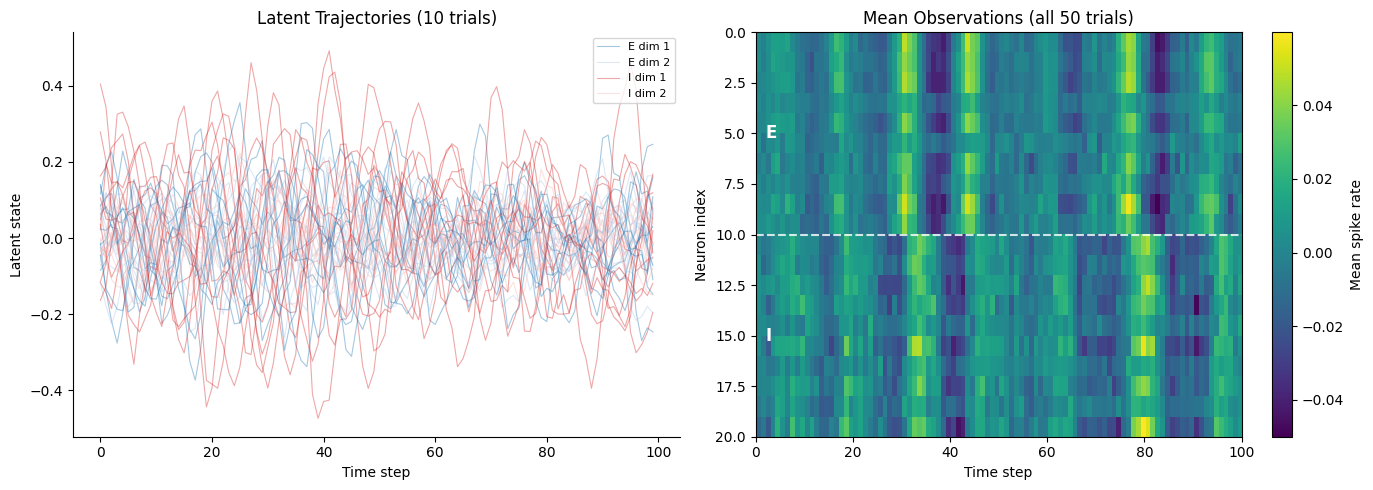

Figure 1.1 saved.


In [8]:
# Cell 1.4 — Figure 1.1: Example states and observations
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: 10 sample latent trajectories, E dims blue shades, I dims red shades
ax = axes[0]
e_colors = ["#1f77b4", "#aec7e8"]  # shades for E latent dims
i_colors = ["#d62728", "#f7b6b2"]  # shades for I latent dims
t_axis = np.arange(T)
n_show = 10  # number of trials to overlay
dim_colors = e_colors + i_colors   # De=2, Di=2
dim_labels = [f'E dim {d+1}' for d in range(De)] + [f'I dim {d+1}' for d in range(Di)]
for trial_idx in range(n_show):
    for d in range(D):
        ax.plot(t_axis, np.array(batched_states[trial_idx, :, d]),
                color=dim_colors[d], alpha=0.4, linewidth=0.8,
                label=dim_labels[d] if trial_idx == 0 else None)
ax.set_xlabel('Time step')
ax.set_ylabel('Latent state')
ax.set_title('Latent Trajectories (10 trials)')
ax.legend(fontsize=8, loc='upper right')
ax.spines['right'].set_visible(False)
ax.spines['top'].set_visible(False)

# Right: mean observation heatmap across all trials
ax = axes[1]
mean_obs = np.mean(np.array(batched_obs), axis=0).T  # (N, T)
im = ax.imshow(mean_obs, aspect='auto', cmap='viridis',
               extent=[0, T, N, 0])
plt.colorbar(im, ax=ax, label='Mean spike rate')
ax.set_xlabel('Time step')
ax.set_ylabel('Neuron index')
ax.set_title('Mean Observations (all 50 trials)')
ax.axhline(Ne, color='white', lw=1.5, linestyle='--', alpha=0.8)
ax.text(T * 0.02, Ne / 2, 'E', color='white', fontsize=12, va='center', fontweight='bold')
ax.text(T * 0.02, Ne + Ni / 2, 'I', color='white', fontsize=12, va='center', fontweight='bold')

plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, "1_data_overview.png"), dpi=150, bbox_inches='tight')
plt.show()
print("Figure 1.1 saved.")

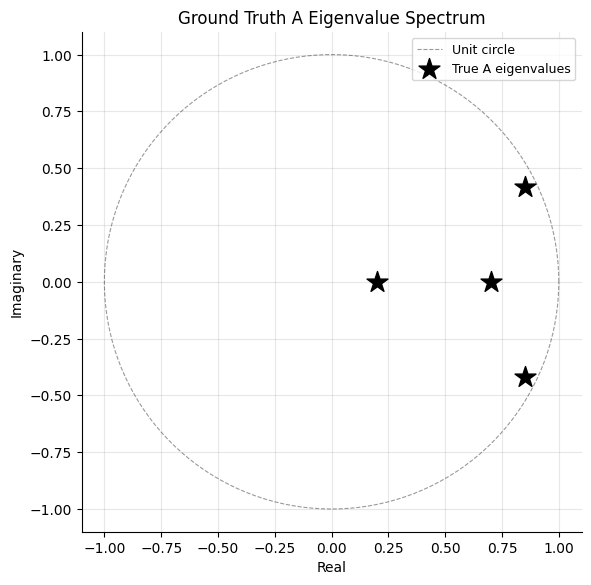

Figure 1.2 saved.


In [9]:
# Cell 1.5 — Figure 1.2: True A eigenvalue spectrum
theta = np.linspace(0, 2 * np.pi, 300)
fig, ax = plt.subplots(figsize=(6, 6))
ax.plot(np.cos(theta), np.sin(theta), 'k--', lw=0.8, alpha=0.4, label='Unit circle')
eigs_true = np.linalg.eigvals(A_true)
ax.scatter(eigs_true.real, eigs_true.imag, marker='*', s=250,
           color='black', zorder=5, label='True A eigenvalues')
ax.set_xlabel('Real')
ax.set_ylabel('Imaginary')
ax.set_title('Ground Truth A Eigenvalue Spectrum')
ax.legend(fontsize=9, loc='upper right')
ax.set_aspect('equal')
ax.grid(True, alpha=0.3)
ax.spines['right'].set_visible(False)
ax.spines['top'].set_visible(False)
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, "1_true_A_eigenvalues.png"), dpi=150, bbox_inches='tight')
plt.show()
print("Figure 1.2 saved.")

## Experiment A: Shared Initialization (CTDS-JAX init applied to all three)

In [10]:
# Cell 2.1 — Get shared init from CTDS-JAX
print("Running CTDS-JAX initialization...")
t0 = time.time()
params_init_shared = ctds_model.initialize(train_datas)
init_time_jax_A = time.time() - t0

A_shared   = np.array(params_init_shared.dynamics.weights)
C_shared   = np.array(params_init_shared.emissions.weights)
Q_shared   = np.array(params_init_shared.dynamics.cov)
R_shared   = np.array(params_init_shared.emissions.cov)
mu0_shared = np.array(params_init_shared.initial.mean)
Q0_shared  = np.array(params_init_shared.initial.cov)

print(f"Shared init done in {init_time_jax_A:.2f}s")
print(f"Initial train LL (CTDS-JAX init): "
      f"{ctds_jax_ll(ctds_model, params_init_shared, train_datas):.4f}")

Running CTDS-JAX initialization...
Y shape (4000, 20)
Shared init done in 4.62s
Initial train LL (CTDS-JAX init): 13.9183


In [11]:
# Cell 2.2 — Create Jeremy model and load shared init; compute initial LL
jeremy_A = CTDSJax(De=De, Di=Di, Ne=Ne, Ni=Ni)
load_params_into_jeremy(jeremy_A, A_shared, C_shared, Q_shared, R_shared, mu0_shared, Q0_shared)
_, _, _, _, jeremy_A_init_ll = jeremy_A.predict(jeremy_train)
print(f"Jeremy initial train LL: {float(jeremy_A_init_ll):.4f}")

Jeremy initial train LL: 13.9183


In [12]:
# Cell 2.3 — Create SSM model and load shared init; compute initial LLs
ssm_A = make_ssm_ctds()
load_params_into_ssm(ssm_A, A_shared, C_shared, Q_shared, R_shared, mu0_shared, Q0_shared)
ssm_A_init_train_ll = ssm_A.log_likelihood(ssm_train_list)
ssm_A_init_test_ll  = ssm_A.log_likelihood(ssm_test_list)
print(f"SSM initial train LL: {ssm_A_init_train_ll:.4f}")
print(f"SSM initial test  LL: {ssm_A_init_test_ll:.4f}")

Assuming Dale's constraints for the weights within regions
Assuming FOF-ADS cross-region constraints if 2 regions, otherwise no cross-region constraints
SSM initial train LL: 14.0746
SSM initial test  LL: 14.7900


In [13]:
# Cell 2.4 — Fit all three and record wall-clock time

# Fit CTDS-JAX
print("Fitting CTDS-JAX (Exp A)...")
t0 = time.time()
params_fitted_A_jax, ll_hist_A_jax = ctds_model.fit_em(
    params_init_shared, train_datas, num_iters=N_EM_ITERS
)
time_A_jax = time.time() - t0
print(f"  Done in {time_A_jax:.1f}s  |  Final train LL: {float(ll_hist_A_jax[-1]):.4f}")

# Fit Jeremy
print("Fitting Jeremy (Exp A)...")
jeremy_A = CTDSJax(De=De, Di=Di, Ne=Ne, Ni=Ni)
load_params_into_jeremy(jeremy_A, A_shared, C_shared, Q_shared, R_shared, mu0_shared, Q0_shared)
t0 = time.time()
jeremy_A.fit(jeremy_train, max_iter=N_EM_ITERS, verbose=False)
time_A_jeremy = time.time() - t0
print(f"  Done in {time_A_jeremy:.1f}s  |  Final train LL: {jeremy_A.ll_history[-1]:.4f}")

# Fit SSM
print("Fitting SSM (Exp A)...")
ssm_A = make_ssm_ctds()
load_params_into_ssm(ssm_A, A_shared, C_shared, Q_shared, R_shared, mu0_shared, Q0_shared)
t0 = time.time()
lls_A_ssm, _ = ssm_A.fit(
    ssm_train_list, method="laplace_em", num_iters=N_EM_ITERS, initialize=False
)
time_A_ssm = time.time() - t0
print(f"  Done in {time_A_ssm:.1f}s  |  Final train LL: {lls_A_ssm[-1]:.4f}")

Fitting CTDS-JAX (Exp A)...


Running for 200 iterations:   0%|          | 0/200 [00:00<?, ?it/s]

  Done in 4.2s  |  Final train LL: 36.1552
Fitting Jeremy (Exp A)...
  Done in 54.3s  |  Final train LL: 36.1764
Fitting SSM (Exp A)...
Assuming Dale's constraints for the weights within regions
Assuming FOF-ADS cross-region constraints if 2 regions, otherwise no cross-region constraints


  0%|          | 0/200 [00:00<?, ?it/s]

  Done in 371.7s  |  Final train LL: 35.6436


In [14]:
# Cell 2.5 — Compute final test LLs and summarize

# CTDS-JAX test LL
jax_A_test_ll  = ctds_jax_ll(ctds_model, params_fitted_A_jax, test_datas)
jax_A_train_ll = ctds_jax_ll(ctds_model, params_fitted_A_jax, train_datas)

# Jeremy test LL
_, _, _, _, jeremy_A_test_ll_arr = jeremy_A.predict(jeremy_test)
jeremy_A_test_ll = float(jeremy_A_test_ll_arr)

# SSM test LL
ssm_A_test_ll  = ssm_A.log_likelihood(ssm_test_list)
ssm_A_train_ll = float(lls_A_ssm[-1])

# Initial LL (CTDS-JAX init is identical for all three in this experiment)
init_ll_shared = ctds_jax_ll(ctds_model, params_init_shared, train_datas)

ll_results_A = {
    "jax": {
        "init_train":  init_ll_shared,
        "final_train": jax_A_train_ll,
        "final_test":  jax_A_test_ll,
        "ll_hist":     list(np.array(ll_hist_A_jax)),
        "time":        time_A_jax,
    },
    "jeremy": {
        "init_train":  float(jeremy_A_init_ll),
        "final_train": float(jeremy_A.ll_history[-1]),
        "final_test":  jeremy_A_test_ll,
        "ll_hist":     list(jeremy_A.ll_history),
        "time":        time_A_jeremy,
    },
    "ssm": {
        "init_train":  ssm_A_init_train_ll,
        "final_train": ssm_A_train_ll,
        "final_test":  ssm_A_test_ll,
        "ll_hist":     list(lls_A_ssm),
        "time":        time_A_ssm,
    },
}

print("\n── Exp A LL Summary ──")
print(f"{'Impl':10s} {'Init Train':>12s} {'Final Train':>12s} {'Final Test':>12s} {'Gap%':>8s}")
for k, lab in zip(["jax", "jeremy", "ssm"], IMPL_LABELS):
    r = ll_results_A[k]
    gap = (oracle_test_ll - r['final_test']) / abs(oracle_test_ll) * 100
    print(f"{lab:10s} {r['init_train']:12.4f} {r['final_train']:12.4f} "
          f"{r['final_test']:12.4f} {gap:8.1f}%")
print(f"{'Oracle':10s} {'':12s} {'':12s} {oracle_test_ll:12.4f} {'0.0%':>8s}")


── Exp A LL Summary ──
Impl         Init Train  Final Train   Final Test     Gap%
CTDS-JAX        13.9183      36.1553      36.0799      0.2%
Jeremy          13.9183      36.1764      36.1298      0.0%
SSM             14.0746      35.6436      35.6188      1.4%
Oracle                                    36.1420     0.0%


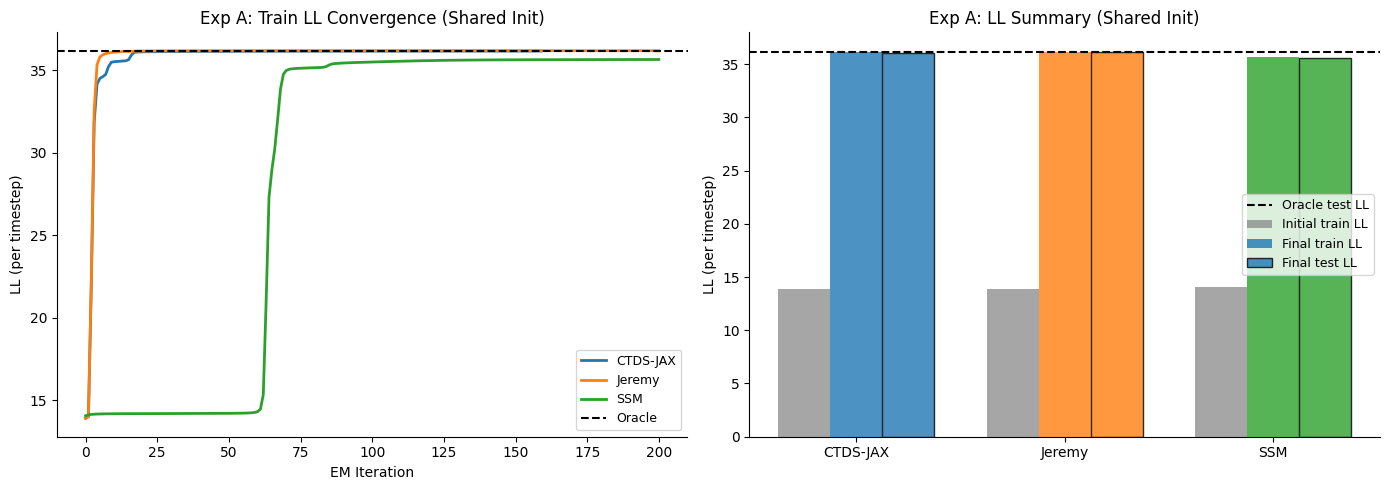

Figure A.1 saved.


In [15]:
# Cell 2.6 — Figure A.1: LL convergence + summary bar
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: train LL convergence
plot_ll_convergence(
    axes[0],
    [ll_results_A[k]["ll_hist"] for k in ["jax", "jeremy", "ssm"]],
    IMPL_COLORS, IMPL_LABELS, oracle_train_ll,
    "Exp A: Train LL Convergence (Shared Init)",
)

# Right: LL summary bar
plot_ll_summary(
    axes[1], IMPL_LABELS,
    [ll_results_A[k]["init_train"]  for k in ["jax", "jeremy", "ssm"]],
    [ll_results_A[k]["final_train"] for k in ["jax", "jeremy", "ssm"]],
    [ll_results_A[k]["final_test"]  for k in ["jax", "jeremy", "ssm"]],
    oracle_test_ll,
    "Exp A: LL Summary (Shared Init)",
    #ax.legend(fontsize=9, loc='upper right')
)

plt.tight_layout()
#plt.savefig(os.path.join(FIG_DIR, "A_ll_convergence.png"), dpi=150, bbox_inches='tight')
plt.show()
print("Figure A.1 saved.")

In [16]:
# Cell 2.7 — Align parameters using Hungarian algorithm for all 3 impls

# Align CTDS-JAX
align_A_jax = align_params(
    A_true, C_true, Q_true,
    np.array(params_fitted_A_jax.dynamics.weights),
    np.array(params_fitted_A_jax.emissions.weights),
    np.array(params_fitted_A_jax.dynamics.cov),
)

# Align Jeremy
align_A_jeremy = align_params(
    A_true, C_true, Q_true,
    np.array(jeremy_A.A),
    np.array(jeremy_A.C),
    np.array(jeremy_A.Q),
)

# Align SSM
align_A_ssm = align_params(
    A_true, C_true, Q_true,
    ssm_A.dynamics.As[0],
    ssm_A.emissions.Cs[0],
    ssm_A.dynamics.Sigmas[0],
)

# Compute Frobenius errors
errs_A_jax    = get_errs(align_A_jax,    np.array(params_fitted_A_jax.emissions.cov))
errs_A_jeremy = get_errs(align_A_jeremy, np.array(jeremy_A.R))
errs_A_ssm    = get_errs(align_A_ssm,    ssm_A.emissions.inv_etas[0])

print("Alignment results (Exp A):")
for label, align, errs in zip(IMPL_LABELS,
                               [align_A_jax, align_A_jeremy, align_A_ssm],
                               [errs_A_jax,  errs_A_jeremy,  errs_A_ssm]):
    collapsed = align['collapsed']
    print(f"  {label}: collapsed={collapsed}, "
          f"A_err={errs[0]:.1f}%, C_err={errs[1]:.1f}%, "
          f"Q_err={errs[2]:.1f}%, R_err={errs[3]:.1f}%")

Alignment results (Exp A):
  CTDS-JAX: collapsed=False, A_err=17.7%, C_err=11.8%, Q_err=87.8%, R_err=2.9%
  Jeremy: collapsed=False, A_err=31.8%, C_err=14.7%, Q_err=91.7%, R_err=2.9%
  SSM: collapsed=False, A_err=39.9%, C_err=18.3%, Q_err=86.1%, R_err=18.5%


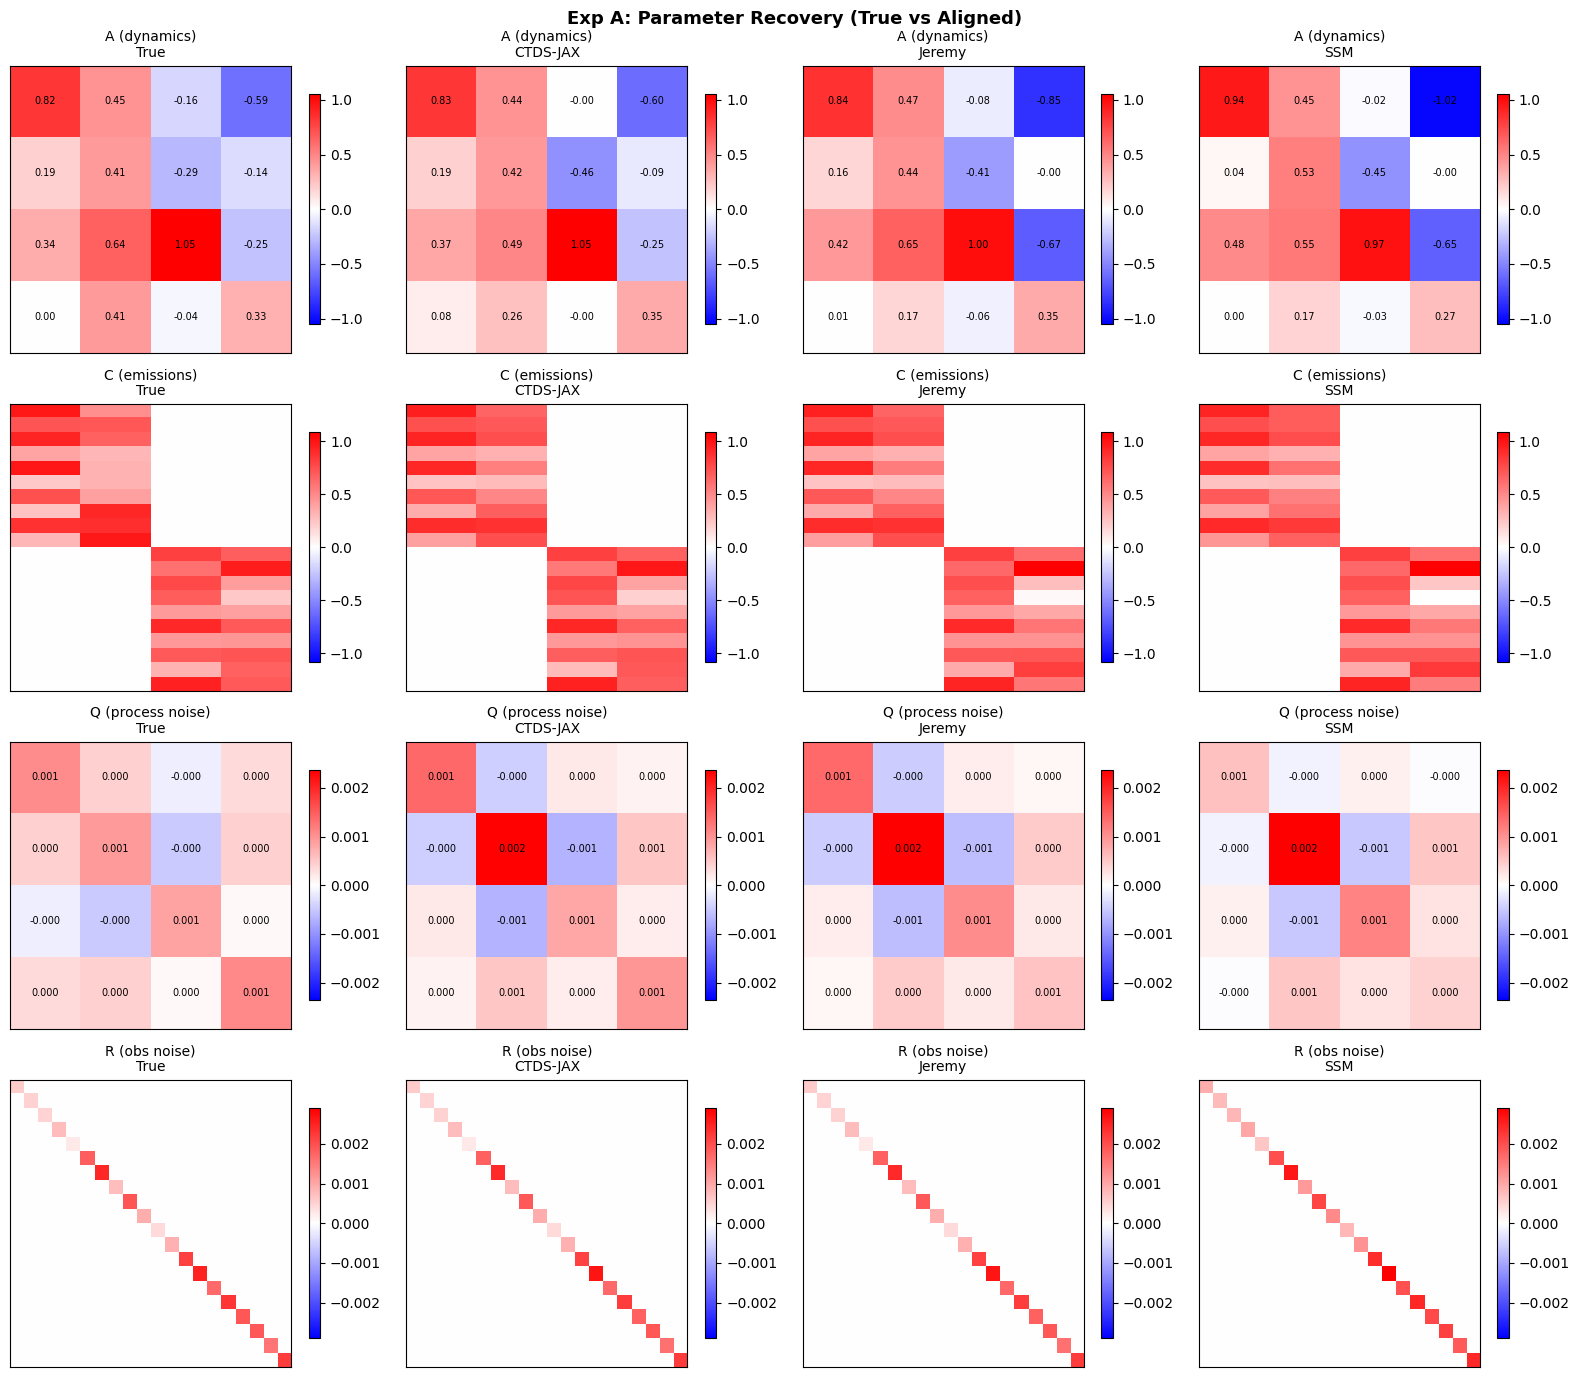

Saved figures/benchmark/A_param_heatmaps.png


In [17]:
# Cell 2.8 — Figure A.2: Parameter recovery heatmaps

def safe_matrix(align_result, key, fallback):
    """Return aligned matrix or fallback if collapsed."""
    if align_result['collapsed']:
        return np.array(fallback)
    return np.array(align_result[key])

A_recs_A = [
    safe_matrix(align_A_jax,    'A_aligned', params_fitted_A_jax.dynamics.weights),
    safe_matrix(align_A_jeremy, 'A_aligned', jeremy_A.A),
    safe_matrix(align_A_ssm,    'A_aligned', ssm_A.dynamics.As[0]),
]
C_recs_A = [
    safe_matrix(align_A_jax,    'C_aligned', params_fitted_A_jax.emissions.weights),
    safe_matrix(align_A_jeremy, 'C_aligned', jeremy_A.C),
    safe_matrix(align_A_ssm,    'C_aligned', ssm_A.emissions.Cs[0]),
]
Q_recs_A = [
    safe_matrix(align_A_jax,    'Q_aligned', params_fitted_A_jax.dynamics.cov),
    safe_matrix(align_A_jeremy, 'Q_aligned', jeremy_A.Q),
    safe_matrix(align_A_ssm,    'Q_aligned', ssm_A.dynamics.Sigmas[0]),
]
R_recs_A = [
    np.array(params_fitted_A_jax.emissions.cov),
    np.array(jeremy_A.R),
    ssm_A.emissions.inv_etas[0],
]

plot_param_heatmaps(
    A_true, C_true, Q_true, R_true,
    A_recs_A, C_recs_A, Q_recs_A, R_recs_A,
    IMPL_LABELS, "Exp A", FIG_DIR, "A_param_heatmaps.png",
)

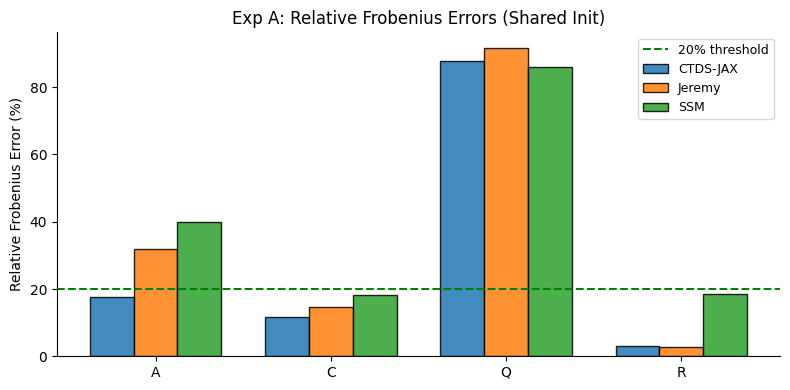

Figure A.3 saved.


In [18]:
# Cell 2.9 — Figure A.3: Frobenius error bar chart
plot_frob_errors(
    [errs_A_jax[0], errs_A_jeremy[0], errs_A_ssm[0]],
    [errs_A_jax[1], errs_A_jeremy[1], errs_A_ssm[1]],
    [errs_A_jax[2], errs_A_jeremy[2], errs_A_ssm[2]],
    [errs_A_jax[3], errs_A_jeremy[3], errs_A_ssm[3]],
    IMPL_LABELS,
    "Exp A: Relative Frobenius Errors (Shared Init)",
    FIG_DIR, "A_frob_errors.png",
)
print("Figure A.3 saved.")

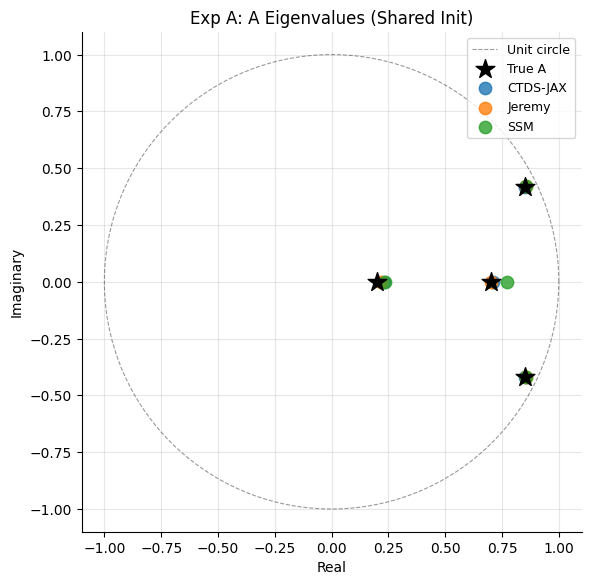

Figure A.4 saved.


In [19]:
# Cell 2.10 — Figure A.4: Eigenvalue comparison
A_recs_eig_A = [
    np.array(params_fitted_A_jax.dynamics.weights),
    np.array(jeremy_A.A),
    ssm_A.dynamics.As[0],
]
plot_eigenvalues(
    A_true, A_recs_eig_A, IMPL_LABELS, IMPL_COLORS,
    "Exp A: A Eigenvalues (Shared Init)",
    FIG_DIR, "A_eigenvalues.png",
)
print("Figure A.4 saved.")

## Experiment B: Native Initialization (each implementation's own init routine)

In [20]:
# Cell 3.1 — CTDS-JAX native init (same as shared; this IS its native init)
print("Running CTDS-JAX native initialization (Exp B)...")
t0 = time.time()
params_init_B_jax = ctds_model.initialize(train_datas)  # native init for CTDS-JAX
init_time_jax_B = time.time() - t0
jax_B_init_train_ll = ctds_jax_ll(ctds_model, params_init_B_jax, train_datas)
print(f"CTDS-JAX native init done in {init_time_jax_B:.2f}s")
print(f"Initial train LL: {jax_B_init_train_ll:.4f}")

# Jeremy native init — EIRNN/NMF-based
print("Running Jeremy native initialization (Exp B)...")
jeremy_B = CTDSJax(De=De, Di=Di, Ne=Ne, Ni=Ni)
t0 = time.time()
jeremy_B.init_params(jeremy_train, init='eirnn', start_seed=0)
init_time_jeremy_B = time.time() - t0
_, _, _, _, jeremy_B_init_ll = jeremy_B.predict(jeremy_train)
print(f"Jeremy native init done in {init_time_jeremy_B:.2f}s")
print(f"Jeremy initial train LL: {float(jeremy_B_init_ll):.4f}")

# SSM native init — handled internally by fit(..., initialize=True)
# We set ssm_B_init_train_ll = np.nan since the initial LL before SSM's own init
# is not meaningfully available before calling fit.
ssm_B_init_train_ll = np.nan
print("SSM will initialize internally during fit (Exp B).")

Running CTDS-JAX native initialization (Exp B)...
Y shape (4000, 20)
CTDS-JAX native init done in 0.56s
Initial train LL: 13.9183
Running Jeremy native initialization (Exp B)...
solving regression
NMF run 1 / 10
NMF run 2 / 10
NMF run 3 / 10
NMF run 4 / 10
NMF run 5 / 10
NMF run 6 / 10
NMF run 7 / 10
NMF run 8 / 10
NMF run 9 / 10
NMF run 10 / 10
Jeremy native init done in 0.19s
Jeremy initial train LL: 33.2348
SSM will initialize internally during fit (Exp B).


In [21]:
# Cell 3.2 — Fit all three with native inits

# Fit CTDS-JAX (native = same as shared)
print("Fitting CTDS-JAX (Exp B)...")
t0 = time.time()
params_fitted_B_jax, ll_hist_B_jax = ctds_model.fit_em(
    params_init_B_jax, train_datas, num_iters=N_EM_ITERS
)
time_B_jax = time.time() - t0
print(f"  Done in {time_B_jax:.1f}s  |  Final train LL: {float(ll_hist_B_jax[-1]):.4f}")

# Fit Jeremy
print("Fitting Jeremy (Exp B)...")
t0 = time.time()
jeremy_B.fit(jeremy_train, max_iter=N_EM_ITERS, verbose=False)
time_B_jeremy = time.time() - t0
print(f"  Done in {time_B_jeremy:.1f}s  |  Final train LL: {jeremy_B.ll_history[-1]:.4f}")

# Fit SSM with native init (initialize=True)
print("Fitting SSM with native init (Exp B)...")
ssm_B = make_ssm_ctds()
t0 = time.time()
lls_B_ssm, _ = ssm_B.fit(
    ssm_train_list, method="laplace_em", num_iters=N_EM_ITERS, initialize=True
)
time_B_ssm = time.time() - t0
# lls_B_ssm[0] is the LL after SSM's own init (before any EM step)
ssm_B_init_train_ll = float(lls_B_ssm[0])
print(f"  Done in {time_B_ssm:.1f}s  |  Final train LL: {lls_B_ssm[-1]:.4f}")
print(f"  SSM initial LL (after its own init): {ssm_B_init_train_ll:.4f}")

Fitting CTDS-JAX (Exp B)...


Running for 200 iterations:   0%|          | 0/200 [00:00<?, ?it/s]

  Done in 7.0s  |  Final train LL: 36.1552
Fitting Jeremy (Exp B)...
  Done in 67.9s  |  Final train LL: 36.1759
Fitting SSM with native init (Exp B)...
Assuming Dale's constraints for the weights within regions
Assuming FOF-ADS cross-region constraints if 2 regions, otherwise no cross-region constraints


  0%|          | 0/1 [00:00<?, ?it/s]

Initializing with an ARHMM using 25 steps of EM.


  0%|          | 0/25 [00:00<?, ?it/s]

  0%|          | 0/200 [00:00<?, ?it/s]

Converged at iteration 92
  Done in 238.7s  |  Final train LL: 23.2898
  SSM initial LL (after its own init): -38.5249


In [22]:
# Cell 3.3 — Compute final test LLs (Exp B) and summarize

jax_B_test_ll  = ctds_jax_ll(ctds_model, params_fitted_B_jax, test_datas)
jax_B_train_ll = ctds_jax_ll(ctds_model, params_fitted_B_jax, train_datas)

_, _, _, _, jeremy_B_test_ll_arr = jeremy_B.predict(jeremy_test)
jeremy_B_test_ll = float(jeremy_B_test_ll_arr)

ssm_B_test_ll  = ssm_B.log_likelihood(ssm_test_list)
ssm_B_train_ll = float(lls_B_ssm[-1])

ll_results_B = {
    "jax": {
        "init_train":  jax_B_init_train_ll,
        "final_train": jax_B_train_ll,
        "final_test":  jax_B_test_ll,
        "ll_hist":     list(np.array(ll_hist_B_jax)),
        "time":        time_B_jax,
    },
    "jeremy": {
        "init_train":  float(jeremy_B_init_ll),
        "final_train": float(jeremy_B.ll_history[-1]),
        "final_test":  jeremy_B_test_ll,
        "ll_hist":     list(jeremy_B.ll_history),
        "time":        time_B_jeremy,
    },
    "ssm": {
        "init_train":  ssm_B_init_train_ll,
        "final_train": ssm_B_train_ll,
        "final_test":  ssm_B_test_ll,
        "ll_hist":     list(lls_B_ssm),
        "time":        time_B_ssm,
    },
}

print("\n── Exp B LL Summary ──")
print(f"{'Impl':10s} {'Init Train':>12s} {'Final Train':>12s} {'Final Test':>12s} {'Gap%':>8s}")
for k, lab in zip(["jax", "jeremy", "ssm"], IMPL_LABELS):
    r = ll_results_B[k]
    gap = (oracle_test_ll - r['final_test']) / abs(oracle_test_ll) * 100
    print(f"{lab:10s} {r['init_train']:12.4f} {r['final_train']:12.4f} "
          f"{r['final_test']:12.4f} {gap:8.1f}%")
print(f"{'Oracle':10s} {'':12s} {'':12s} {oracle_test_ll:12.4f} {'0.0%':>8s}")


── Exp B LL Summary ──
Impl         Init Train  Final Train   Final Test     Gap%
CTDS-JAX        13.9183      36.1553      36.0799      0.2%
Jeremy          33.2348      36.1759      36.1284      0.0%
SSM            -38.5249      23.2898      23.5189     34.9%
Oracle                                    36.1420     0.0%


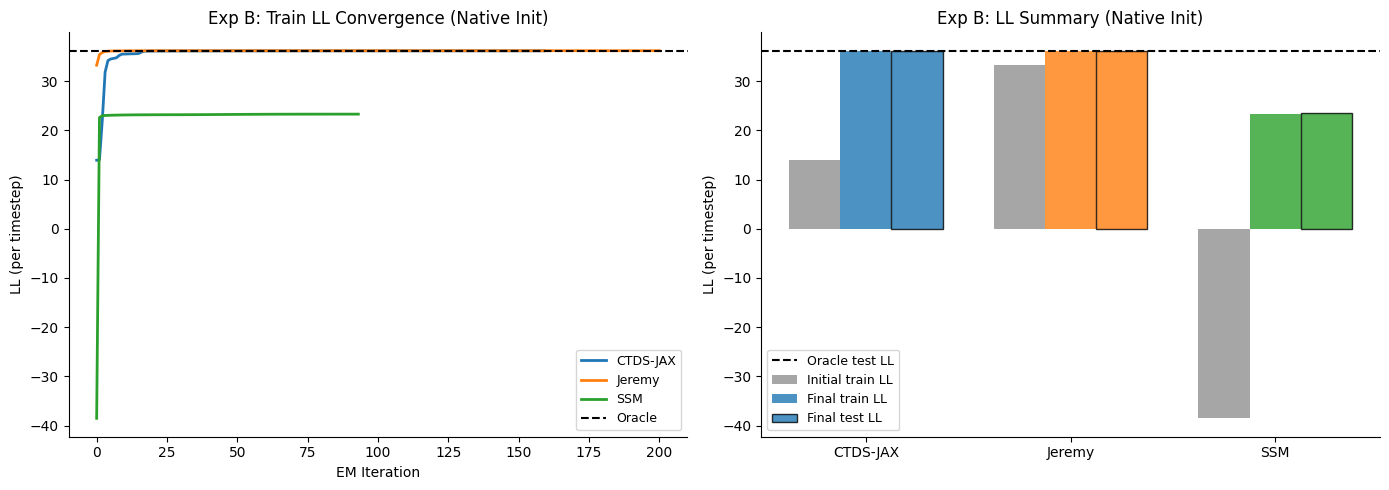

Figure B.1 saved.


In [23]:
# Cell 3.4 — Figure B.1: LL convergence + summary bar (Exp B)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

plot_ll_convergence(
    axes[0],
    [ll_results_B[k]["ll_hist"] for k in ["jax", "jeremy", "ssm"]],
    IMPL_COLORS, IMPL_LABELS, oracle_train_ll,
    "Exp B: Train LL Convergence (Native Init)",
)
plot_ll_summary(
    axes[1], IMPL_LABELS,
    [ll_results_B[k]["init_train"]  for k in ["jax", "jeremy", "ssm"]],
    [ll_results_B[k]["final_train"] for k in ["jax", "jeremy", "ssm"]],
    [ll_results_B[k]["final_test"]  for k in ["jax", "jeremy", "ssm"]],
    oracle_test_ll,
    "Exp B: LL Summary (Native Init)",
)
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, "B_ll_convergence.png"), dpi=150, bbox_inches='tight')
plt.show()
print("Figure B.1 saved.")

In [24]:
# Cell 3.5 — Align parameters (Exp B)
align_B_jax = align_params(
    A_true, C_true, Q_true,
    np.array(params_fitted_B_jax.dynamics.weights),
    np.array(params_fitted_B_jax.emissions.weights),
    np.array(params_fitted_B_jax.dynamics.cov),
)
align_B_jeremy = align_params(
    A_true, C_true, Q_true,
    np.array(jeremy_B.A),
    np.array(jeremy_B.C),
    np.array(jeremy_B.Q),
)
align_B_ssm = align_params(
    A_true, C_true, Q_true,
    ssm_B.dynamics.As[0],
    ssm_B.emissions.Cs[0],
    ssm_B.dynamics.Sigmas[0],
)

errs_B_jax    = get_errs(align_B_jax,    np.array(params_fitted_B_jax.emissions.cov))
errs_B_jeremy = get_errs(align_B_jeremy, np.array(jeremy_B.R))
errs_B_ssm    = get_errs(align_B_ssm,    ssm_B.emissions.inv_etas[0])

print("Alignment results (Exp B):")
for label, align, errs in zip(IMPL_LABELS,
                               [align_B_jax, align_B_jeremy, align_B_ssm],
                               [errs_B_jax,  errs_B_jeremy,  errs_B_ssm]):
    print(f"  {label}: collapsed={align['collapsed']}, "
          f"A_err={errs[0]:.1f}%, C_err={errs[1]:.1f}%, "
          f"Q_err={errs[2]:.1f}%, R_err={errs[3]:.1f}%")

Alignment results (Exp B):
  CTDS-JAX: collapsed=False, A_err=17.7%, C_err=11.8%, Q_err=87.8%, R_err=2.9%
  Jeremy: collapsed=False, A_err=19.6%, C_err=12.5%, Q_err=67.9%, R_err=2.9%
  SSM: collapsed=True, A_err=nan%, C_err=nan%, Q_err=nan%, R_err=nan%


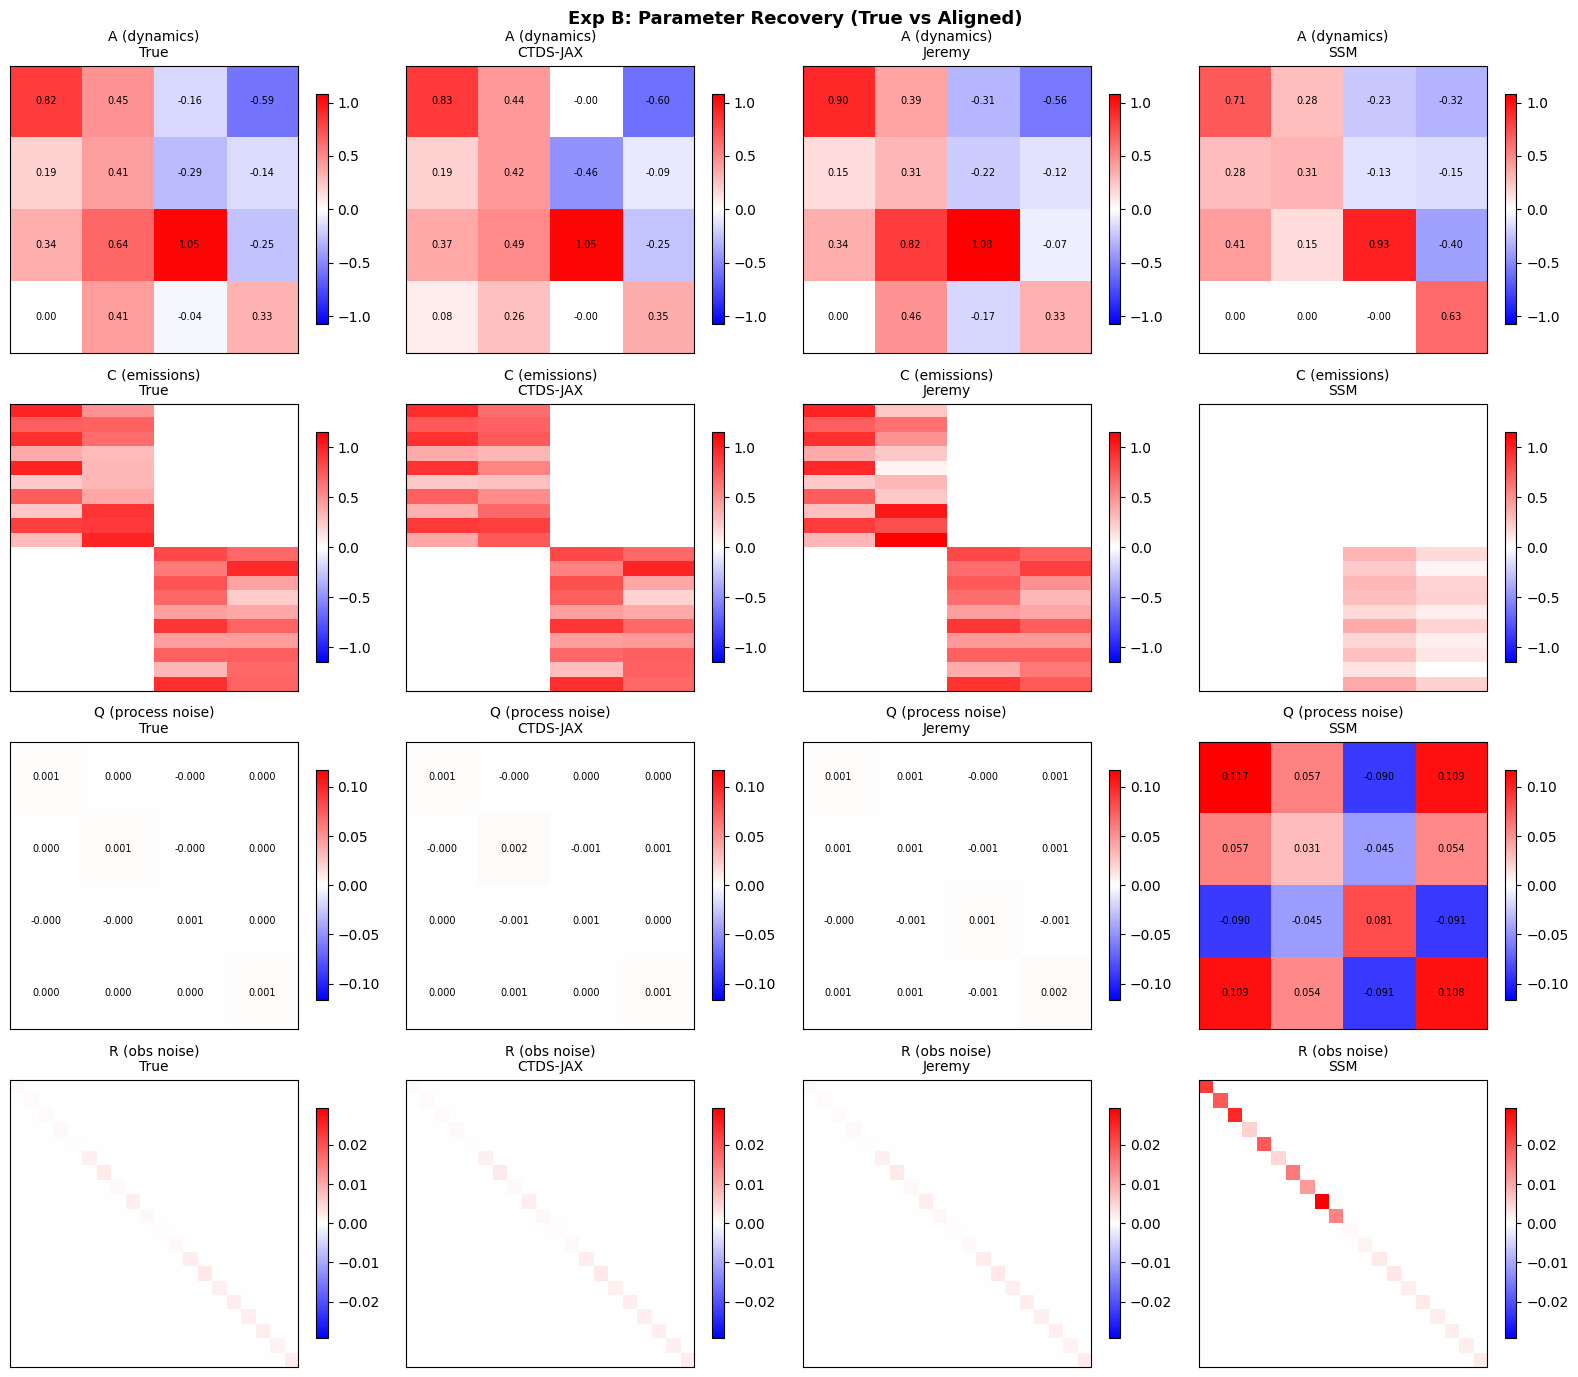

Saved figures/benchmark/B_param_heatmaps.png


In [25]:
# Cell 3.6 — Figure B.2: Parameter recovery heatmaps (Exp B)
A_recs_B = [
    safe_matrix(align_B_jax,    'A_aligned', params_fitted_B_jax.dynamics.weights),
    safe_matrix(align_B_jeremy, 'A_aligned', jeremy_B.A),
    safe_matrix(align_B_ssm,    'A_aligned', ssm_B.dynamics.As[0]),
]
C_recs_B = [
    safe_matrix(align_B_jax,    'C_aligned', params_fitted_B_jax.emissions.weights),
    safe_matrix(align_B_jeremy, 'C_aligned', jeremy_B.C),
    safe_matrix(align_B_ssm,    'C_aligned', ssm_B.emissions.Cs[0]),
]
Q_recs_B = [
    safe_matrix(align_B_jax,    'Q_aligned', params_fitted_B_jax.dynamics.cov),
    safe_matrix(align_B_jeremy, 'Q_aligned', jeremy_B.Q),
    safe_matrix(align_B_ssm,    'Q_aligned', ssm_B.dynamics.Sigmas[0]),
]
R_recs_B = [
    np.array(params_fitted_B_jax.emissions.cov),
    np.array(jeremy_B.R),
    ssm_B.emissions.inv_etas[0],
]
plot_param_heatmaps(
    A_true, C_true, Q_true, R_true,
    A_recs_B, C_recs_B, Q_recs_B, R_recs_B,
    IMPL_LABELS, "Exp B", FIG_DIR, "B_param_heatmaps.png",
)

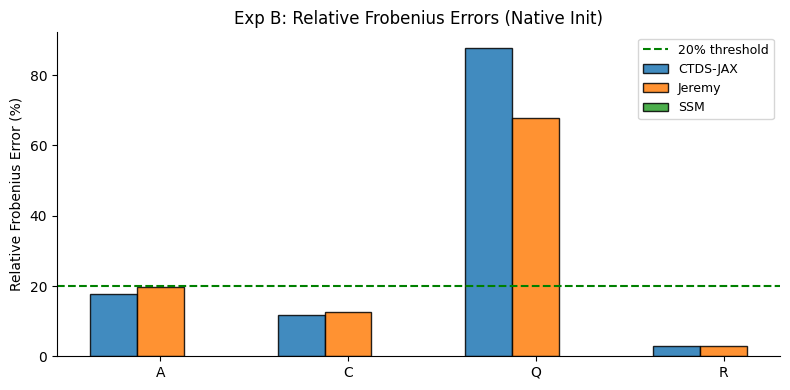

Figure B.3 saved.


In [26]:
# Cell 3.7 — Figure B.3: Frobenius error bar chart (Exp B)
plot_frob_errors(
    [errs_B_jax[0], errs_B_jeremy[0], errs_B_ssm[0]],
    [errs_B_jax[1], errs_B_jeremy[1], errs_B_ssm[1]],
    [errs_B_jax[2], errs_B_jeremy[2], errs_B_ssm[2]],
    [errs_B_jax[3], errs_B_jeremy[3], errs_B_ssm[3]],
    IMPL_LABELS,
    "Exp B: Relative Frobenius Errors (Native Init)",
    FIG_DIR, "B_frob_errors.png",
)
print("Figure B.3 saved.")

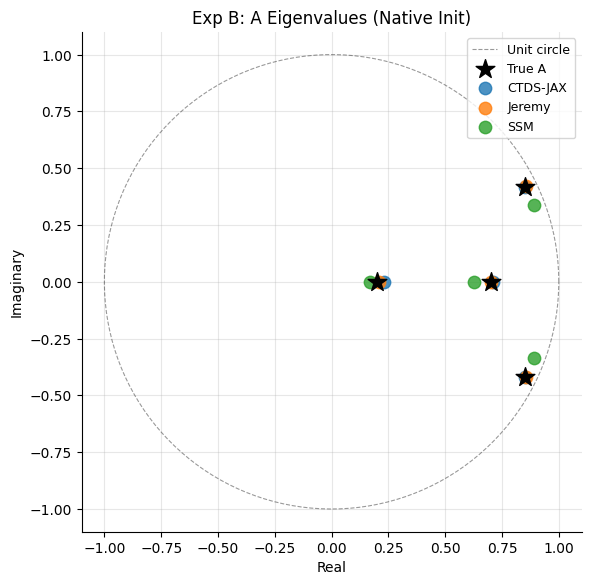

Figure B.4 saved.


In [27]:
# Cell 3.8 — Figure B.4: Eigenvalue comparison (Exp B)
A_recs_eig_B = [
    np.array(params_fitted_B_jax.dynamics.weights),
    np.array(jeremy_B.A),
    ssm_B.dynamics.As[0],
]
plot_eigenvalues(
    A_true, A_recs_eig_B, IMPL_LABELS, IMPL_COLORS,
    "Exp B: A Eigenvalues (Native Init)",
    FIG_DIR, "B_eigenvalues.png",
)
print("Figure B.4 saved.")